In [319]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [320]:
def f(x):
  return 3*x**2 - 4*x + 5

In [321]:
f(3.0)

20.0

In [322]:
xs = np.arange(-5,5,0.25)

In [323]:
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [324]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

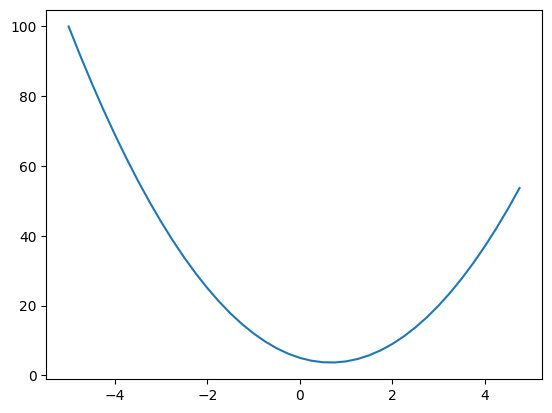

In [325]:
plt.plot(xs,ys)

In [326]:
h = 0.001
x = 3.0
f(x)

20.0

In [327]:
f(x+h)


20.014003000000002

In [328]:
f(x+h) - f(x)

0.01400300000000243

In [329]:
(f(x+h) - f(x))/h

14.00300000000243

In [330]:
# let us get more complex
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
d

4.0

In [331]:
a = 2.0
b = -3.0
c = 10.0
h = 0.0001


d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [383]:
class Value:

  def __init__(self,data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._backward = lambda: None
    self.grad = 0.0
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self,other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self,other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data *out.grad

    out._backward = _backward

    return out

  def __pow__(self,other):
    assert isinstance(other, (int,float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad

    out._backward = _backward
    return out

  def __rmul__(self,other): # other * self
    return self * other

  def __truediv__(self,other): # self / other
    return self * other**-1


  def __neg__(self): # self
    return self * -1

  def __sub__(self,other): # self, other
    return self + (-other)
  def __radd__(self, other):
    return self + other
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad = out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0

    for node in reversed(topo):
      node._backward()


a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b;
e.label = 'e'
d = e + c;
d.label = 'd'
f = Value(-2.0, label = 'f')
L = d + f;
L.label = 'L'
a, b, a + b, a*b, a*b + c, (a.__mul__(b)).__add__(c)

(Value(data = 2.0),
 Value(data = -3.0),
 Value(data = -1.0),
 Value(data = -6.0),
 Value(data = 4.0),
 Value(data = 4.0))

In [333]:
d._prev

{Value(data = -6.0), Value(data = 10.0)}

In [334]:
d._op

'+'

In [335]:
from graphviz import Digraph

def trace(root):
  # build a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot



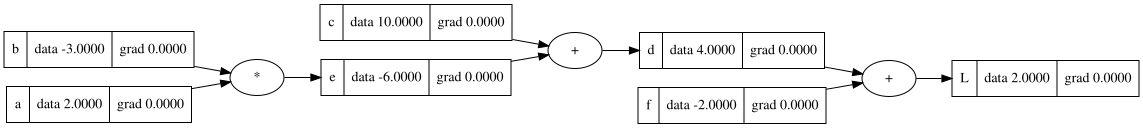

In [336]:
draw_dot(L)

In [337]:
c.grad = -2.0
e.grad = -2.0

In [338]:
L.grad = 1.0

In [339]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

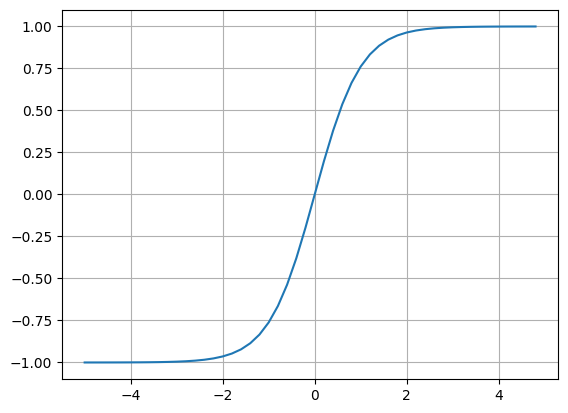

In [340]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [341]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b

x1w1 = x1*w1;
x1w1.label = 'x1*w1'
x2w2 = x2*w2;
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b;
n.label = 'n'
o = n.tanh();
o.label = 'o'



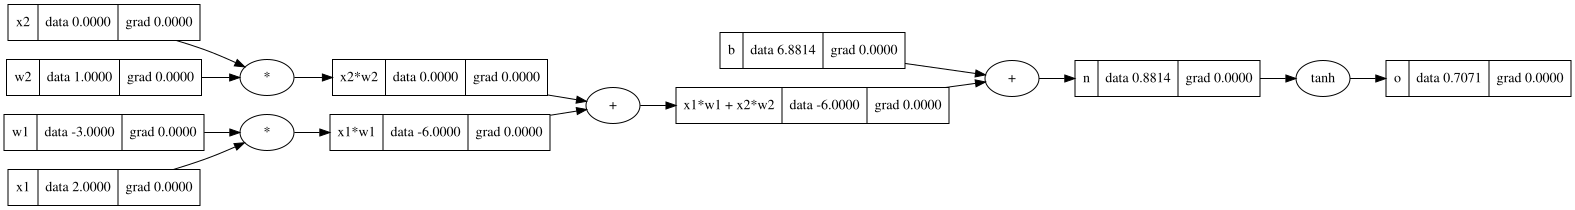

In [342]:
draw_dot(o)

In [343]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [344]:
x1w1.grad = 0.5
x2w2.grad = 0.5


In [345]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [346]:
o.grad = 1.0
o._backward()

In [347]:
n._backward()

In [348]:
b._backward()

In [349]:
x1w1x2w2._backward()

In [350]:
x1w1._backward()
x2w2._backward()

In [351]:
o.backward()

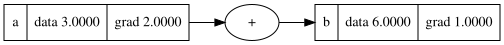

In [352]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

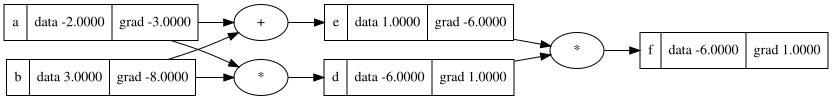

In [353]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a*b; d.label ='d'
e = a + b; e.label = 'e'
f = d*e; f.label = 'f'

f.backward()
draw_dot(f)


In [354]:
a = Value(2.0)
b = Value(4.0)
a/b, a-b

(Value(data = 0.5), Value(data = -2.0))

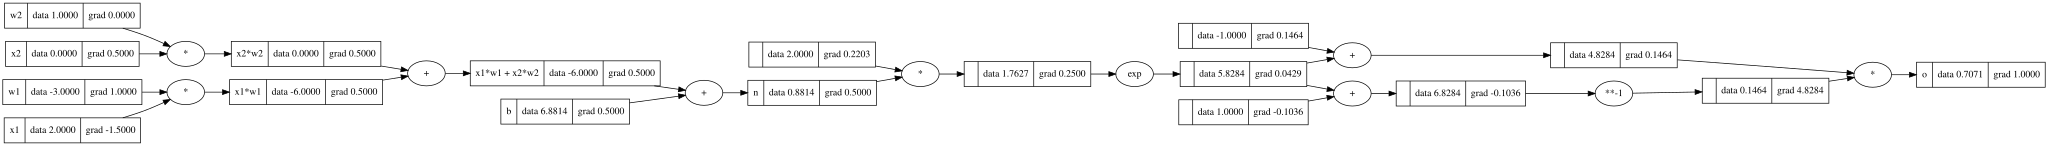

In [355]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b

x1w1 = x1*w1;
x1w1.label = 'x1*w1'
x2w2 = x2*w2;
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b;
n.label = 'n'

# ----
e = (2*n).exp()
o = (e-1)/(e+1)

# ---
o.label = 'o'
o.backward()
draw_dot(o)


In [356]:
import torch

In [357]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())



0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [359]:
import random

In [399]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i] , sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]



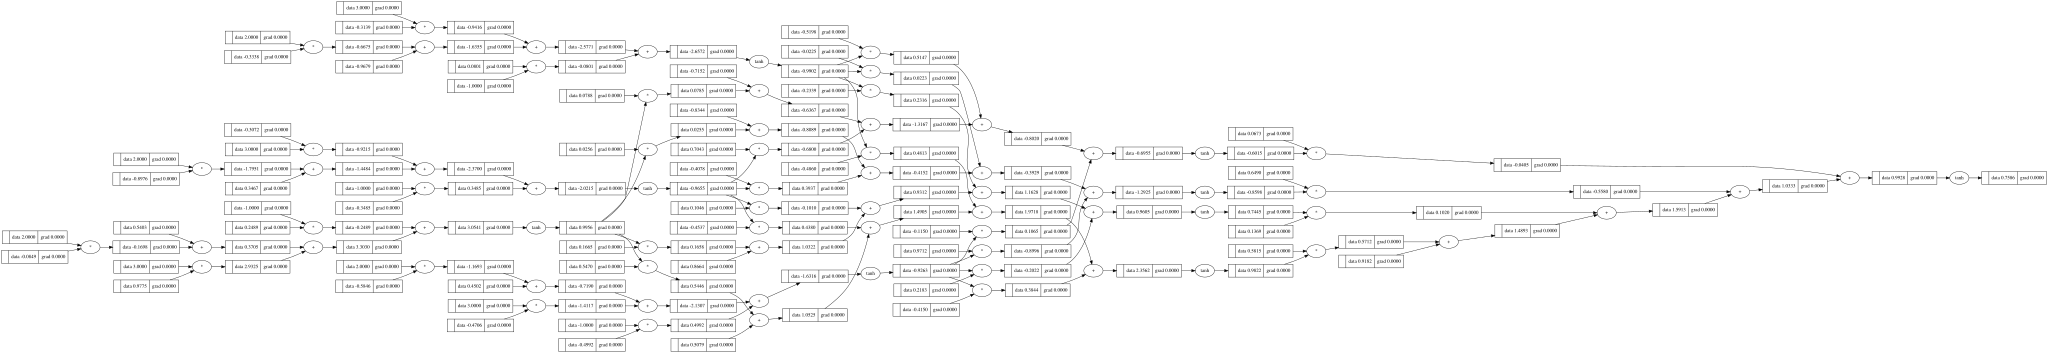

In [374]:
draw_dot(n(x))

In [403]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]


ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [n(x) for x in xs]
ypred

[Value(data = -0.40031883342196767),
 Value(data = -0.8989926386454566),
 Value(data = -0.8836798214751296),
 Value(data = -0.34586492561255855)]

In [404]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data = 3.795978104210223)

In [405]:
loss.backward()

In [408]:
n.layers[0].neurons[0].w[0].grad

-0.12295108194574544

In [464]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data = 0.9274524616630204)

In [401]:
n.parameters()

[Value(data = 0.832746836658774),
 Value(data = -0.5358711538440482),
 Value(data = 0.7674313441176503),
 Value(data = 0.575772571184868),
 Value(data = -0.040881562707183905),
 Value(data = -0.23801618616279296),
 Value(data = -0.6492332201973843),
 Value(data = 0.9693608797390736),
 Value(data = 0.1299138706119578),
 Value(data = -0.8551022723642772),
 Value(data = 0.8749498303114638),
 Value(data = -0.43531341899456866),
 Value(data = 0.5049136835001504),
 Value(data = -0.612121647475794),
 Value(data = 0.8210615122058367),
 Value(data = 0.9527576197281427),
 Value(data = 0.47036043110674775),
 Value(data = -0.8278570673263179),
 Value(data = 0.15413775566626886),
 Value(data = 0.20370349835628643),
 Value(data = 0.5948534762242885),
 Value(data = -0.9418744066691489),
 Value(data = 0.21299445281363427),
 Value(data = -0.1602823902450614),
 Value(data = -0.3732167923669816),
 Value(data = -0.9826588349340004),
 Value(data = 0.6918061644142497),
 Value(data = 0.5769622479476257),
 Va

In [402]:
len(n.parameters())

41

In [461]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [459]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data = 7.878833478680267e-07)

In [460]:
loss.backward()

In [462]:
ypred

[Value(data = 0.9999972012063995),
 Value(data = -0.9993365464762741),
 Value(data = -0.9994103447383916),
 Value(data = 0.9999965928111745)]

In [471]:
for k in range(100):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 0.0009670616179952571
1 0.0009650059970198774
2 0.0009629590911210237
3 0.0009609208449514977
4 0.000958891203632056
5 0.0009568701127465277
6 0.0009548575183369052
7 0.0009528533668985734
8 0.0009508576053755171
9 0.0009488701811556413
10 0.0009468910420661055
11 0.0009449201363688003
12 0.0009429574127557994
13 0.0009410028203448726
14 0.0009390563086751224
15 0.0009371178277025962
16 0.0009351873277960024
17 0.000933264759732462
18 0.0009313500746932972
19 0.0009294432242599
20 0.0009275441604096676
21 0.0009256528355119063
22 0.0009237692023238853
23 0.00092189321398687
24 0.0009200248240222237
25 0.0009181639863275876
26 0.0009163106551730224
27 0.000914464785197321
28 0.0009126263314042655
29 0.0009107952491589368
30 0.0009089714941841415
31 0.0009071550225568021
32 0.0009053457907044257
33 0.0009035437554016104
34 0.0009017488737666306
35 0.0008999611032579696
36 0.0008981804016709666
37 0.0008964067271345203
38 0.0008946400381077856
39 0.0008928802933768662
40 0.0008911274520

In [472]:
ypred

[Value(data = 0.9901903954775192),
 Value(data = -0.9874416164213079),
 Value(data = -0.9823250972419447),
 Value(data = 0.9847594532593912)]